# SBI CMB lensing

In [1]:
import subprocess
import numpy as np
import matplotlib.pyplot as plt
from classy import Class
import numpy as np
import camb
from camb import model

import sys
sys.path.append("../")

from CMB_lensing_SBI.cmb_lensing_sbi_pipe import *
import healpy as hp
from pixell import enmap
from pixell import curvedsky as cs
from pixell import enmap,lensing as plensing,curvedsky, utils, enplot
from orphics import io,maps,stats
from falafel import qe
import frogress
import re
import glob
import sys
import timeit
import mnms
from mnms import noise_models as nm
import os
os.environ['SOFIND_SYSTEM'] = 'niagara'
import gc
from scipy.interpolate import interp1d

# some config -------------
path_files = '/project/r/rbond/jaejoonk/lensing_pipeline_data/'


beam_fwhm = 1.4


# maps config --------------
nside= 4096 # this is needed for the kappa map and the kappa_alm to lens the CMB maps. nside 1024 is good up to l ~2k., nside 4096 should pobably be our default here.
arcmin_res_car = 1# this somehow determines also the resolution of the CAR maps. can't be too small. 
lmax = 2500 #6000 is the default for the ACT pipeline; but we can't really do it as class can't generate lensing cls a l>2500 (unlensed ones, yes, so when we will use N-bdy sims it will be OK)



#### ACT configs -----------


'''

Note: v4 ~ is the unreleased version.

The observations were made using three
dichroic detector modules, known as polarization arrays
(PA), with PA4 observing in the f150 (PA4 f150) and
f220 (PA4 f220) bands; PA5 in the f090 (PA5 f090) and
f150 (PA5 150) bands, and PA6 in the f090 (PA6 f090)
and f150 (PA6 f150) bands.

the lensing map did not utilize the 220GHz data, only 90 and 150GHz, hence only pa4a (not pa4b),
while the other arrays will have both the pa{5-6}a and pa{5-6}b data 
https://arxiv.org/pdf/2304.05202

'''


data_maps_fn_pattern = 'sim_cmb_night_%s_%s_%s_3pass_1way_set%s_map.fits'
m = 'night'
a_f = ['pa4_f150','pa5_f090','pa5_f150','pa6_f090','pa6_f150']
#qids = ['pa4av4', 'pa5av4', 'pa5bv4', 'pa6av4','pa6bv4'] 
qids = ['pa4a', 'pa5a', 'pa5b', 'pa6a','pa6b'] 



array_dict = {'pa4a': 'pa4_f150', 'pa5a': 'pa5_f090', 'pa5b': 'pa5_f150','pa6a': 'pa6_f090', 'pa6b': 'pa6_f150'}


gain_dict =  {
             "pa4_f150": 0.9708, "pa4_f220": 1.1119, "pa5_f090": 0.9625,
             "pa5_f150": 0.9961, "pa6_f090": 0.9660, "pa6_f150": 0.9764,
             }


# I assume they're the same as v4?
pol_eff = {
            'pa4a': 0.9584, 'pa5a': 0.9646, 'pa5b': 0.9488,
            'pa6a': 0.9789, 'pa6b': 0.9656
        }







global_folder = path_files
catalog_large = global_folder + 'catalog_large/union_catalog_large_20220316.csv'
catalog_regular = global_folder +'catalog_regular/union_catalog_regular_20220316.csv'
nemomodel_f090 = global_folder+ '/nemomodel_f090/nemomodel_dr6_all_clustersSNR5090down2.fits'
nemomodel_f150 = global_folder+ '/nemomodel_f150/nemomodel_dr6_all_clustersSNR5150down2.fits'
beams_path = global_folder+ '/beams_path/20230902/'
szbeam150 = global_folder+ '/szbeam150/s16_pa2_f150_nohwp_night_beam_tform_jitter.txt'
szbeam90 =  global_folder+ '/szbeam90/s16_pa3_f090_nohwp_night_beam_tform_jitter.txt'
calibration = global_folder+ 'calibration/tf_fit_dr6_%s_%s.dat'
kcoadded_alms=  'kcoadd_data_tszsub_%s_%s.fits'


MULTIPLE_SPLITS = True


if MULTIPLE_SPLITS:
    nsplits = 8
    data_run = False
    model_subtract_tsz = False
else:
    nsplits = 1
    data_run = False
    model_subtract_tsz = False
    
    
    
    
output_folder_general = '/scratch/r/rbond/jaejoonk/CMB_lensing_maps/sims/'
#MULTIPLE_SPLITS = True
add_noise = True
sim_num = 0
cosmology = 'fiducial'
if add_noise:
    noise = 'noisy'
else:
    noise = 'noiseless'

if MULTIPLE_SPLITS:
    spl = '8split'
else:
    spl = '1split'     
        
outdir = output_folder_general+'{0}_{1}_{2}_{3}/'.format(cosmology,noise,sim_num,spl)

try:
    os.mkdir(outdir)
except OSError as e:
    print(e)
    pass
    
timing_container = dict()

[Errno 17] File exists: '/scratch/r/rbond/jaejoonk/CMB_lensing_maps/sims/fiducial_noisy_0_8split/'


# CLASS settings

In [2]:
params = dict()
params['root']   = './'
params['output'] = 'dTk'
#params['nbody_gauge_transfer_functions'] = 'y'
params['P_k_max_h/Mpc']   = 100
        
#####LCDM parameter####
        
params['Omega_b']   = 0.049000
params['Omega_cdm'] = 0.268500
params['h']         = 0.671100
params['tau_reio']  = 0.054308
params['sigma8']    = 0.834000
params['n_s']       = 0.962400
params['Omega_fld'] = 0. #682500



#params['w0_fld']    = -1.
#params['Omega_Lambda']= 0.000



params['format']    = 'CAMB'

params['write primordial'] = 'yes'
params['write background'] = 'yes'
params['write parameters'] = 'yes'
params['write thermodynamics'] = 'yes'
params['write warnings'] = 'yes'
params['headers'] = 'yes'
        
#params['overwrite_root'] = 'y'
       
params['input_verbose'] = 1
params['background_verbose'] = 10
params['thermodynamics_verbose'] = 1
params['perturbations_verbose'] = 1
params['transfer_verbose'] = 1
params['primordial_verbose'] = 1
params['spectra_verbose'] = 1
params['nonlinear_verbose'] = 1
params['lensing_verbose'] = 1
params['output_verbose'] = 1
        
        
        
params['N_ur'] = 2.0328
params['N_ncdm'] = 1
params['deg_ncdm'] = 1
params['T_ncdm'] = 0.71611
        
        
########axion parameters#######
params['scf_potential'] = 'axion'
params['n_axion'] = 3.000000 #1

##one can pass either:
params['log10_axion_ac'] = -3.500000 #-3.531
params['fraction_axion_ac'] = 0.0001 #0.000100 #0.1

##one also needs to specify scf_param = phi_i, phi_ini_dot
params['scf_parameters'] = '2.7,0.' #1.5,0.0
########################

#####extra EDE parameters#####
#keep as is for standard runs#
##we do not use the fluid approximation##
params['scf_evolve_as_fluid'] = 'no' 	
#params['scf_evolve_as_fluid_always'] = 'no'
params['scf_evolve_like_axionCAMB'] = 'no'
params['do_shooting'] =  'yes'  ##controls overall shooting; useful when debugging
params['do_shooting_scf'] = 'yes' ##controls shooting for scf only; useful when debugging.
params['scf_has_perturbations'] = 'yes'
params['attractor_ic_scf'] ='no' 
params['compute_phase_shift'] = 'no' ##one can ask to compute the phase_shift imprinted by the EDE following Baumann et al. JCAP01(2016)007
params['loop_over_background_for_closure_relation']= 'yes' ##this is required because we do not necessarily know the value of Omega_EDE today and therefore the closure relation needs to be enforced otherwise. for the usual n=3 EDE this is not really relevant, but it may be for n=1.

####################################

#####precision parameters#####
#keep as is for standard runs#
params['adptative_stepsize'] = 1000
params['precision_newton_method_F'] = 1e-3   ####be careful when playing with these parameters if theta_s is shoot for (we recommend running on H for MCMC); but often required to be set to 1e-2 or 1e-3 for EDE shooting to converged.
params['precision_newton_method_x'] = 1e-3  ####be careful when playing with these parameters if theta_s is shoot for (we recommend running on H for MCMC); but often required to be set to 1e-2 or 1e-3 for EDE shooting to converged.
params['precision_loop_over_background'] = 1e-3 ### precision with which we will be enforcing the closure relation



###################################
params['z_max_pk'] = '100.'
params['lensing']= 'yes' 
params['output']= 'tCl,pCl,lCl,mPk'         
    
    
# COMPUTE TT EE BB POWER SPECTRA WITH CLASS ------------------------------------------------------------------------------------------------------------

# Initialize the CLASS cosmological model
cosmo = Class()
cosmo.set(params)  # Set the cosmological parameters; replace 'params' with your actual parameters
cosmo.compute()   # Compute the cosmological observables

# Get the lensed and unlensed CMB power spectra up to lmax
lensed_cls = cosmo.lensed_cl(min([lmax,2500])) 
unlensed_cls = cosmo.raw_cl(min([lmax,3000])) 


CosmoSevereError: 

Error in Class: input_read_from_file(L:417) :error in input_shooting(pfc,ppr,pba,pth,ppt,ptr,ppm,phr,pfo,ple,psd,pop, input_verbose, &has_shooting, errmsg);
=>input_shooting(L:830) :error in input_try_unknown_parameters(&A_s, 1, &fzw, &sigma8_or_S8, errmsg);
=>input_try_unknown_parameters(L:1416) :error in thermodynamics_init(&pr,&ba,&th);
=>thermodynamics_init(L:342) :error in thermodynamics_helium_from_bbn(ppr,pba,pth);
=>thermodynamics_helium_from_bbn(L:589) :could not open fA with name /gpfs/fs0/scratch/r/rbond/jaejoonk/modules/class_public/external/bbn/sBBN_2017.dat and mode "r"

# CAMB settings (from notebook)

In [2]:
# Initialize CAMB parameters
# Initialize CAMB parameters
pars = camb.CAMBparams()

# Set cosmological parameters
pars.set_cosmology(H0=67.02393, ombh2=0.02219218, omch2=0.1203058, omk=0, tau=0.06574325)
pars.set_dark_energy(w=-1, cs2=1)
pars.InitPower.set_params(As=2.15086031154146e-9, ns=0.9625356, pivot_scalar=0.05)

# Set other cosmological parameters
pars.YHe = 0.2448964
pars.TCMB = 2.7255

# Set reionization parameters
pars.Reion.Reionization = True
pars.Reion.use_optical_depth = True
pars.Reion.optical_depth = 0.06574325
pars.Reion.delta_redshift = 0.5
pars.Reion.z_re_helium = 3.5
pars.Reion.z_start = 5.0

# Set scalar, tensor, and vector settings
pars.WantScalars = True
pars.WantTensors = False
pars.WantVectors = False

# Set accuracy parameters
pars.set_accuracy(AccuracyBoost=3, lAccuracyBoost=3)
pars.HighAccuracyDefault = True
pars.DoLateRadTruncation = True
pars.max_eta_k = 20000.0
pars.set_for_lmax(10000, lens_potential_accuracy=3)

# Set lensing and other related parameters
pars.WantLensing = True
pars.lensing_method = 1
pars.Alens = 1.0

# Set neutrino parameters
pars.num_massive_neutrinos = 1
pars.m_nu = [0.06]  
pars.nnu = 2.046  # Total number of effective neutrinos

# Set non-linear parameters
pars.NonLinear = model.NonLinear_both
pars.NonLinearModel.set_params(halofit_version='mead2020')  # Use 'mead2020' or other versions if preferred

# Set additional parameters from the ini file
pars.ombh2 = 0.02219218
pars.omch2 = 0.1203058
pars.omnuh2 = 0.00064
pars.scalar_spectral_index = [0.9625356]
pars.scalar_nrun = [0]
pars.scalar_nrunrun = [0]
pars.accurate_polarization = True
pars.accurate_reionization = True
pars.accurate_BB = False
pars.use_physical = True
pars.initial_condition = 1
pars.feedback_level = 1
pars.output_file_headers = True
pars.number_of_threads = 0
pars.use_spline_template = True
# Set Gaussian terms if needed (these seem to be related to reionization tuning)
# Commented out as they are typically not exposed directly in the Python API
# pars.AGauss1 = -0.14
# pars.AGauss2 = 0.079
# pars.zGauss1 = 7.28
# pars.zGauss2 = 6.73
# pars.wGauss1 = 0.18
# pars.wGauss2 = 0.33

# Set output filenames, though these are more relevant for file output
# pars.scalar_output_file = 'scalCls.dat'
# pars.lensed_output_file = 'lensedCls.dat'
# pars.lens_potential_output_file = 'lenspotentialCls.dat'


# Initialize the power spectrum
results = camb.get_results(pars)

# Get the CMB power spectra
powers = results.get_cmb_power_spectra(pars, CMB_unit='muK', raw_cl=True)

lensed_cls1 = {'tt': powers['lensed_scalar'][:,0], 'te': powers['lensed_scalar'][:,3],
              'ee': powers['lensed_scalar'][:,1], 'bb': powers['lensed_scalar'][:,2],
              'pp': powers['lens_potential'][:,0]}


# CAMB settings (from ini file)

In [63]:
if not os.path.exists(outdir+'/lensed_and_beams_alms.npy'):
    if cosmology == 'fiducial':
        camb_filename = '../data/cosmo2017_10K_acc3_params.ini'

    # it's really this simple!
    pars = camb.read_ini(camb_filename)
    results = camb.get_results(pars)

    # CMB_unit set to None to exclude ~1e12 factor,
    # raw_cl to give me Cl not l(l+1)/2pi Cl
    powers = results.get_cmb_power_spectra(pars, CMB_unit='muK', raw_cl=True)


    unlensed_cls = {'tt': powers['unlensed_scalar'][:,0], 'te': powers['unlensed_scalar'][:,3],
                    'ee': powers['unlensed_scalar'][:,1], 'bb': powers['unlensed_scalar'][:,2]}

    lensed_cls = {'tt': powers['lensed_scalar'][:,0], 'te': powers['lensed_scalar'][:,3],
                  'ee': powers['lensed_scalar'][:,1], 'bb': powers['lensed_scalar'][:,2],
                  'pp': powers['lens_potential'][:,0]}



In [64]:
lensed_cls['pp']

NameError: name 'lensed_cls' is not defined

# LET'S MAKE TT,EE,BB and KAPPA maps. Let's also lens TT,EE,BB

In [4]:
'''
Let's generate some TT,TE.. using CLASS (it will be useful in the long run).
I don't think it will matter for this test if these are all slightly different..

'''

print ('----- MAKE ALMS  ------')
print ('')
done_ = True


while done_:

#    try:
    if not os.path.exists(outdir+'/lensed_and_beams_alms.npy'):
        st = timeit.default_timer()

        # Generate TT, EE, EB, BB power spectra from unlensed alms
        ps = np.array([[unlensed_cls['tt'], unlensed_cls['te'], 0 * unlensed_cls['te']],
                       [unlensed_cls['te'], unlensed_cls['ee'], 0 * unlensed_cls['te']],
                       [0 * unlensed_cls['tt'], 0 * unlensed_cls['te'], 0 * unlensed_cls['bb']]])

        # Generate random alms (spherical harmonic coefficients) for the power spectra
        alms_ = cs.rand_alm(ps, ainfo=None, lmax=lmax, seed=None, dtype=np.complex128, m_major=True, return_ainfo=False)

        # Convert alms to Healpix maps
        T_map = hp.alm2map(alms_[0], nside=nside)
        E_map = hp.alm2map(alms_[1], nside=nside)
        B_map = hp.alm2map(alms_[2], nside=nside)


        np.save(outdir+'/unlensed_alms',alms_)


        # Compute the power spectra of the maps
        T_cl = hp.anafast(T_map)
        E_cl = hp.anafast(E_map)
        B_cl = hp.anafast(B_map)

        # Assuming T_cl, E_cl, B_cl, unlensed_cls, and lmax are defined
        ell = np.arange(len(T_cl))


        ############################################################################################################

        ############################################################################################################
        fig, axs = plt.subplots(1, 3, figsize=(10, 3))

        # Plot TT
        axs[0].plot(T_cl[:lmax] * ell[:lmax], label='map TT')
        axs[0].plot(unlensed_cls['tt'][:lmax] * ell[:lmax], label='Unlensed TT')
        axs[0].set_xscale('log')
        axs[0].set_title('TT')
        axs[0].set_xlabel('Multipole moment (ell)')
        axs[0].set_ylabel('Power Spectrum')
        axs[0].legend()

        # Plot EE
        axs[1].plot(E_cl[:lmax] * ell[:lmax], label='map EE')
        axs[1].plot(unlensed_cls['ee'][:lmax] * ell[:lmax], label='Unlensed EE')
        axs[1].set_xscale('log')
        axs[1].set_title('EE')
        axs[1].set_xlabel('Multipole moment (ell)')
        axs[1].set_ylabel('Power Spectrum')
        axs[1].legend()

        # Plot BB
        axs[2].plot(B_cl[:lmax] * ell[:lmax], label='map BB')
        axs[2].plot(unlensed_cls['bb'][:lmax] * ell[:lmax], label='Unlensed BB')
        axs[2].set_xscale('log')
        axs[2].set_title('BB')
        axs[2].set_xlabel('Multipole moment (ell)')
        axs[2].set_ylabel('Power Spectrum')
        axs[2].legend()

        # Adjust layout for better spacing
        plt.tight_layout()
        plt.show()
        ############################################################################################################



        ###### compute kappa and lens maps --------------------------------------------------

        # Make a noiseless kappa map
        ell_ = np.arange(len(lensed_cls['pp']))  # Define ell array for the power spectrum
        kappa_cmb = hp.synfast((lensed_cls['pp'] * (ell_ * (ell_ + 1) / 2)**2), nside=nside, lmax=lmax)  # Generate kappa map using the lensing potential power spectrum


        # Compute alms from the kappa map


        kappa_cmb_alm = hp.map2alm(kappa_cmb,lmax=lmax)  # Convert kappa map to spherical harmonics coefficients (alms)

        np.save(outdir+'/kappa_cmb_alm',kappa_cmb_alm)



        ell, emm = hp.Alm.getlm(lmax=lmax)  # Get ell and m values for the alms

        # Convert kappa alms to phi alms (lensing potential)
        phi_cmb_alm = kappa_cmb_alm / (ell * (ell + 1) / 2)  # Calculate the lensing potential alms
        phi_cmb_alm[ell==0] = 1e-30
        # Define the shape and WCS (World Coordinate System) for the map
        shape, wcs = enmap.fullsky_geometry(res=np.deg2rad(arcmin_res_car/60.), proj="car")  # Set map resolution to 1 arcminute

        # Generate lensed T, E, and B maps from the alms and lensing potential
        maps_ = pixell.lensing.lens_map_curved((3, shape[0], shape[1]), wcs, phi_cmb_alm, alms_, phi_ainfo=None, maplmax=None, dtype=np.float64, spin=[0, 2], output="l", geodesic=True, verbose=False, delta_theta=None)

        # Convert the lensed maps to alms
        alm_TEB = pixell.curvedsky.map2alm(maps_[0], lmax=lmax, spin=[0, 2])

        np.save(outdir+'/lensed_alms',alm_TEB)




        # Apply beam -----------------
        alm_TEB[0] = cs.almxfl(alm_TEB[0], lambda ell: gauss_beam(ell, beam_fwhm))
        alm_TEB[1] = cs.almxfl(alm_TEB[1], lambda ell: gauss_beam(ell, beam_fwhm))
        alm_TEB[2] = cs.almxfl(alm_TEB[2], lambda ell: gauss_beam(ell, beam_fwhm))

        np.save(outdir+'/lensed_and_beams_alms',alm_TEB)

        # Compute the power spectra from the beam-applied alms
        cl_T_lensed_hp = hp.alm2cl(alm_TEB[0])
        cl_E_lensed_hp = hp.alm2cl(alm_TEB[1])
        cl_B_lensed_hp = hp.alm2cl(alm_TEB[2])

        # Convert the beam-applied alms back to maps
        #map_T_lensed_hp, map_E_lensed_hp, map_B_lensed_hp = hp.alm2map(alm_TEB, nside=nside, pol=False)

        # Calculate the beam function for the given FWHM
        tht_fwhm = np.deg2rad(beam_fwhm / 60.)
        f_beam = np.exp(-(tht_fwhm**2) * (np.arange(lmax)**2) / (16 * np.log(2.)))


        ############################################################################################################

        fig, axs = plt.subplots( 1,3, figsize=(10, 3))

        # TT plot
        axs[0].plot(ell[:lmax], T_cl[:lmax] / unlensed_cls['tt'][:lmax] , label='Unlensed TT')
        axs[0].plot(ell[:lmax], cl_T_lensed_hp[:lmax] / unlensed_cls['tt'][:lmax] , label='Lensed TT')
        axs[0].plot(ell[:lmax], lensed_cls['tt'][:lmax]*f_beam**2 / unlensed_cls['tt'][:lmax] , label='CLASS Lensed TT')
        axs[0].plot(ell[:lmax], unlensed_cls['tt'][:lmax] / unlensed_cls['tt'][:lmax] )
        axs[0].set_xscale('log')
        axs[0].set_title('TT Power Spectrum')
        axs[0].set_xlabel(r'$\ell$')
        axs[0].set_ylabel(r'$C_\ell^{TT}$')
        axs[0].legend()

        # EE plot
        axs[1].plot(ell[:lmax], E_cl[:lmax] / unlensed_cls['ee'][:lmax], label='Unlensed EE')
        axs[1].plot(ell[:lmax], cl_E_lensed_hp[:lmax] / unlensed_cls['ee'][:lmax], label='Lensed EE')
        axs[1].plot(ell[:lmax], lensed_cls['ee'][:lmax]*f_beam**2 / unlensed_cls['ee'][:lmax], label='CLASS Lensed EE')
        axs[1].plot(ell[:lmax], unlensed_cls['ee'][:lmax] / unlensed_cls['ee'][:lmax], label='Reference')
        axs[1].set_xscale('log')
        axs[1].set_title('EE Power Spectrum')
        axs[1].set_xlabel(r'$\ell$')
        axs[1].set_ylabel(r'$C_\ell^{EE}$')


        # BB plot
        axs[2].plot(ell[:lmax], cl_B_lensed_hp[:lmax] / lensed_cls['bb'][:lmax]/f_beam**2 , label='Lensed BB')
        axs[2].set_xscale('log')
        axs[2].set_title('BB Power Spectrum')
        axs[2].set_xlabel(r'$\ell$')
        axs[2].set_ylabel(r'$C_\ell^{BB}$')

        # Adjust layout
        plt.tight_layout()
        plt.show()



        ############################################################################################################
        end = timeit.default_timer()
        done_ = False

        del T_map
        del E_map
        del B_map
        del alms_
        del kappa_cmb
        del kappa_cmb_alm
        del phi_cmb_alm
        del maps_
        gc.collect()   
        timing_container['generate_alms'] = end - st
    else:
        print ('loading alms from disk')
        alm_TEB = np.load(outdir+'/lensed_and_beams_alms.npy',allow_pickle=True)#.item()
        done_ = False

#    except:
#        print ('failed, redoing it')


----- MAKE ALMS  ------

loading alms from disk


# Let's add noise and create multiple channels

This will automatically make 0.5' maps; it's in the mask wcs

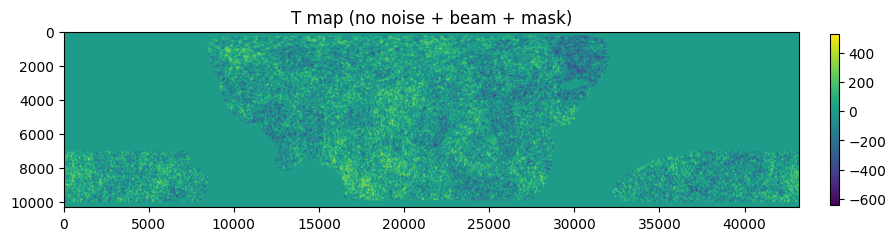

In [5]:
# Define paths to the mask and noise simulation files
st = timeit.default_timer()

mask_path = path_files + "/mask/act_mask_fejer1_20220316_GAL070_rms_70.00_downgrade_None.fits"
noise_path = '/noise_sims_path/noise_sims/'

# Read the mask map
mask = enmap.read_map(mask_path)

# Create an empty map to fill with noise
full_shape, full_wcs = mask.shape, mask.wcs
imap = enmap.empty((3,) + full_shape, full_wcs, dtype=np.float32)

# Convert the alms to a map, convolved with the beam
sigmap_conv = cs.alm2map(alm_TEB, imap)

del alm_TEB
gc.collect()

# Apply the mask to the map (set regions with mask < 0.25 to 0)
sigmap_conv[:, mask < 0.25] = 0

# Handle NaN values in the map (set them to 0)
sigmap_conv[~np.isfinite(sigmap_conv)] = 0

# Plot the temperature (T) map
plt.figure(figsize=(10, 5))
data = sigmap_conv[0].data
im = plt.imshow(np.array(data))  # Plot the T map
plt.title('T map (no noise + beam + mask)')
im_ratio = data.shape[0]/data.shape[1]
plt.colorbar(im,fraction=0.046 * im_ratio, pad=0.04)
#plt.colorbar(label='Intensity')
plt.show()

the noise on each array is correlated between the two frequency channels, because the two channels have copointing pixels

but the noise is ~independent between different arrays

so each noise model is distinct for each array, but joint for each channel on the array 

In [6]:
if MULTIPLE_SPLITS:
    if add_noise:
    #if 1==1:
        # a qid is an identifier tag for a dataset, like a detector array.
        # see sofind for a list of possible qids depending on which data
        # model you load. thus, in the below, could also do ['pa4a', 'pa4b'] 
        # or ['pa6a', 'pa6b']
        #qids_ = ['pa5a', 'pa5b'] 
        #qids_ = ['pa6b']#, 'pa5b'] 
        #qids_ = np.array([q[:-2] for q in qids])
        # this will load a baseline-map noise model for act_dr6v4. could also 
        # do (for example) 'act_dr6v4_pwv_split' for pwv split maps (likewise el_split, inout_split), or `act_dr6.01` for dr6.01 products. these
        # correspond to the name of noise_model config files in the noise_model
        # product of sofind
        config_name = 'act_dr6.01_cmbmask' 

        # this will load the tiled noise model. could also do 'fdw_cmbmask'
        # for directional wavelet model (or 'tile', 'wav', or 'fdw' for
        # dr6.01; see noise_models product configs in sofind). these correspond
        # to the blocks within the config file
        noise_model_name = 'fdw'


        # if you are loading a config that requires subproduct_kwargs (e.g.,  
        # 'act_dr6v4_pwv_split' maps require a 'pwv_split' argument), you need
        # to specify which subproduct_kwargs the model will include at object
        # creation. this could be nothing (e.g., for 'act_dr6v4'),
        # {'pwv_split': ['pwv1']} (e.g, for 'act_dr6v4_pwv_split'), or may be
        # a longer list like {'inout_split': ['inout1', 'inout2']} (e.g., for
        # 'act_dr6v4_inout_split'). in the latter case, passing a pair of qids
        # will result in 4 "datasets" (the outer product of all the qids and
        # subproduct_kwargs in the list) being jointly modeled/covaried.
        subproduct_kwargs = {}
        # subproduct_kwargs = {'inout_split': ['inout1', 'inout2']}

        # instantiate NoiseModel object



        for split_i in range(nsplits):

            for qids_ in [['pa4a', 'pa4b'] , ['pa5a', 'pa5b'], ['pa6a', 'pa6b'] ]:

                if not os.path.exists(outdir+'/noise_{0}_{1}_{2}.npy'.format(sim_num,split_i,qids_[-1])):
                    tnm = nm.BaseNoiseModel.from_config(
                        config_name,
                        noise_model_name,
                        *qids_,
                        **subproduct_kwargs
                        )

                    # grab a sim from disk, generate on-the-fly if does not exist
                    my_sim = tnm.get_sim(split_num=split_i, sim_num=sim_num, lmax=5400)#,check_on_disk=True)#, generate=True)


                    for i,q in enumerate(qids_):
                        map_out = mnms.utils.fourier_resample(my_sim[i] ,  shape=full_shape, wcs=full_wcs)#, dtype=None)
                        np.save(outdir+'/noise_{0}_{1}_{2}'.format(sim_num,split_i,q),map_out[0])

        print ('done')
        ## grab a sim from disk, fail if does not exist on-disk
        #my_sim = tnm.get_sim(split_num=2, sim_num=16, lmax=10800, generate=False)
        #
        ## generate a sim on-the-fly whether or not exists on disk
        #my_sim = tnm.get_sim(split_num=2, sim_num=16, lmax=10800, check_on_disk=False)


done


In [20]:
#my_sim = tnm.get_sim(split_num=split_i, sim_num=200, lmax=5400)

In [11]:
if MULTIPLE_SPLITS:

    for split in range(nsplits):
        print ('split #',split)
        for i,af in enumerate(a_f):
            print ('--- channel ',af)
            if not os.path.exists(f"{outdir}sim_cmb_{m}_{af}_{sim_num}_3pass_1way_set{split}_map_srcfree.fits"):

                froot = "/home/r/rbond/jaejoonk/project/lensing_pipeline_data/dr6.01/maps/" #'/home/s/sievers/kaper/scratch/maps/dr6v3_20211031/'
                fname = "{0}/act_dr6.01_wide_{1}_night_8way_set{2}_ivar.fits".format(froot,af,split) #f"{froot}cmb_{m}_{a}_{f}_8way_coadd_ivar.fits"
                ivar = enmap.read_map(fname)


                #the products are the same, but in truth they are different: 
                #the ivar for E and B are 0.5 * ivar for T. 
                #the product is ivar for T
                ivar_stack = []
                ivar_stack.append(ivar)
                ivar_stack.append(0.5*ivar)
                ivar_stack.append(0.5*ivar)
                ivar_stack = enmap.enmap(np.stack(ivar_stack), ivar.wcs)


                #seed = int(i)+5
                #wn_map = white_noise((3,)+full_shape,full_wcs,seed = seed,div=ivar)
                if add_noise:
                    map_out = np.load(outdir+'/noise_{0}_{1}_{2}.npy'.format(sim_num,split,qids[i]),allow_pickle=True)
                    totmap = (sigmap_conv+map_out)#sims_noise[sim_num][split_i][qids[i]][0])
                else:
                    totmap = copy.deepcopy(sigmap_conv)
                totmap[:,mask<0.25] = 0 
                totmap[np.isnan(totmap)] = 0
               # totmap_dict[af] = totmap

                #'''

                enmap.write_map(f"{outdir}sim_cmb_{m}_{af}_{sim_num}_3pass_1way_set{split}_ivar.fits",ivar_stack)
                enmap.write_map(f"{outdir}sim_cmb_{m}_{af}_{sim_num}_3pass_1way_set{split}_map_srcfree.fits",totmap)


                del totmap
                del ivar
                del ivar_stack

                gc.collect()


    print ('Done')

else:


    for split in range(nsplits):
        print ('split #',split)
        for i,af in enumerate(a_f):
            print ('--- channel ',af)
            if not os.path.exists(f"{outdir}sim_cmb_{m}_{af}_{sim_num}_3pass_1way_set{split}_map_srcfree.fits"):
                froot = path_files + "ivar/" #'/home/s/sievers/kaper/scratch/maps/dr6v3_20211031/'
                fname = "{0}/cmb_night_{1}_3pass_4way_coadd_ivar.fits".format(froot,af)

                print(fname)

                ivar = enmap.read_map(fname)#/0.000001


                #the products are the same, but in truth they are different: 
                #the ivar for E and B are 0.5 * ivar for T. 
                #the product is ivar for T
                ivar_stack = []
                ivar_stack.append(ivar)
                ivar_stack.append(0.5*ivar)
                ivar_stack.append(0.5*ivar)
                ivar_stack = enmap.enmap(np.stack(ivar_stack), ivar.wcs)


                seed = int(i)+5
                wn_map = white_noise((3,)+full_shape,full_wcs,seed = seed,div=ivar)
                if add_noise:
                    totmap = (sigmap_conv+wn_map)
                else:
                    totmap = copy.deepcopy(sigmap_conv)
                totmap[:,mask<0.25] = 0 
                totmap[np.isnan(totmap)] = 0
               # totmap_dict[af] = totmap

                #'''

                enmap.write_map(f"{outdir}sim_cmb_{m}_{af}_{sim_num}_3pass_1way_set{split}_ivar.fits",ivar_stack)
                enmap.write_map(f"{outdir}sim_cmb_{m}_{af}_{sim_num}_3pass_1way_set{split}_map_srcfree.fits",totmap)

                #del totmap
                del wn_map
                del ivar_stack
                gc.collect()
    print ('Done')


split # 0
--- channel  pa4_f150
--- channel  pa5_f090
--- channel  pa5_f150
--- channel  pa6_f090
--- channel  pa6_f150
split # 1
--- channel  pa4_f150
--- channel  pa5_f090
--- channel  pa5_f150
--- channel  pa6_f090
--- channel  pa6_f150
split # 2
--- channel  pa4_f150
--- channel  pa5_f090
--- channel  pa5_f150
--- channel  pa6_f090
--- channel  pa6_f150
split # 3
--- channel  pa4_f150
--- channel  pa5_f090
--- channel  pa5_f150
--- channel  pa6_f090
--- channel  pa6_f150
split # 4
--- channel  pa4_f150
--- channel  pa5_f090
--- channel  pa5_f150
--- channel  pa6_f090
--- channel  pa6_f150
split # 5
--- channel  pa4_f150
--- channel  pa5_f090
--- channel  pa5_f150
--- channel  pa6_f090
--- channel  pa6_f150
split # 6
--- channel  pa4_f150
--- channel  pa5_f090
--- channel  pa5_f150
--- channel  pa6_f090
--- channel  pa6_f150
split # 7
--- channel  pa4_f150
--- channel  pa5_f090
--- channel  pa5_f150
--- channel  pa6_f090
--- channel  pa6_f150
Done


In [10]:
 #############################
plt.figure(figsize=(10, 5))
plt.imshow(np.array(totmap[0].data),vmin = -500,vmax=500)#, grid=False)
plt.title('T map (noise + beam + mask)')
plt.colorbar(label='Intensity')
plt.show()


end = timeit.default_timer()
timing_container['add_noise'] = end - st

NameError: name 'totmap' is not defined

<Figure size 1000x500 with 0 Axes>

# downgrade

Sect 5.1 [https://arxiv.org/pdf/2304.05202]

The sky maps are produced at a resolution of 0.5′
but because our lensing reconstruction uses a maximum
CMB multipole of ℓmax = 3000, a downgraded pixel
resolution of 1′ is sufficient for the unbiased recovery
of the lensing power spectrum and reduces computation
time. Therefore, we downgrade the CMB data maps
by block-averaging neighbouring CMB pixels. Similarly,
the inverse-variance maps are downgraded by summing
the contiguous full-resolution inverse-variance values.




we're also doing the stacking of different splits:

Sect 5.6 [https://arxiv.org/pdf/2304.05202]

We first define for each array-frequency’s data the
map-based coadd map c, an unbiased estimate of the
sky signal, by taking the inverse-variance-weighted average of the eight split maps m_i


(Note we should also create 4 coadd-split maps, coadding  together split j and j + 4 with
j ∈ {0, 1, 2, 3})

In [12]:
print ('----- DOWNGRADE  ------')
print ('')
st = timeit.default_timer()

calibrated = True

for qid in qids:
    print (qid)
    # get frequencies --------
    array_freq = array_dict[qid]
    array = array_freq[:3]
    freq = array_freq[4:]


    # NOISE MAPS --------------------
    if not os.path.exists(outdir+'/map_downgraded_ivar_{0}_{1}_{2}'.format(array,freq,sim_num)):
        stack = []
        for sset in np.arange(nsplits):
            ivarfn = re.sub("_map", "_ivar", data_maps_fn_pattern) % (array, freq, sim_num,sset)
            mul = 1. / gain_dict[array_dict[qid]] if calibrated else 1.
            omap = enmap.read_map(outdir+ivarfn) * mul
            stack.append(omap)
        smap = enmap.enmap(np.stack(stack), omap.wcs)

        del stack
        gc.collect()
        smap_downgraded = enmap.downgrade(smap, 2, op = np.sum)
        enmap.write_map(outdir+'/map_downgraded_ivar_{0}_{1}_{2}'.format(array,freq,sim_num), smap_downgraded)

        del smap_downgraded
        del smap
        gc.collect()

    # DATA + NOISE MAPS ------------
    if not os.path.exists(outdir+'/map_downgraded_srcfree_{0}_{1}_{2}'.format(array,freq,sim_num)):
        stack = []
        for sset in np.arange(nsplits):
            ivarfn = re.sub("_map", "_map_srcfree", data_maps_fn_pattern) % (array, freq, sim_num,sset)
            mul = 1. / gain_dict[array_dict[qid]] if calibrated else 1.
            omap = enmap.read_map(outdir+ivarfn) * mul
            stack.append(omap)
        smap = enmap.enmap(np.stack(stack), omap.wcs)

        del stack
        gc.collect()
        smap_downgraded = enmap.downgrade(smap, 2, op = np.sum)
        enmap.write_map(outdir+'/map_downgraded_srcfree_{0}_{1}_{2}'.format(array,freq,sim_num), smap_downgraded)

        del smap_downgraded
        del smap
        gc.collect()


end = timeit.default_timer()
timing_container['downgrade'] = end - st


----- DOWNGRADE  ------

pa4a
pa5a
pa5b
pa6a
pa6b


# inpaint

Sect 5.2 [https://arxiv.org/pdf/2304.05202]


As described in Section 3.5, we work with
maps in which point sources above a threshold of roughly
4–10 mJy (corresponding to an SNR threshold of 4σ)
have been fit and subtracted at the map level.

However,
very bright and/or extended sources may still have residuals in these maps. To address this, we prepare a catalog
of 1779 objects for masking with holes of radius 6′
: these
include especially bright sources that require a specialized point-source treatment in the map-maker (see Aiola
et al. 2020; Naess et al. 2020), extended sources with
SNR > 10 identified through cross-matching with external catalogs, all point sources with SNR > 70 at f150
and an additional list of locations with residuals from
point-source subtraction that were found by visual inspection. We include an additional set of 14 objects for
masking with holes of radius 10′
: these are regions of
diffuse or extended positive emission identified by eye
in matched-filtered co-adds of ACT maps. They include nebulae, Galactic dust knots, radio lobes and large
nearby galaxies.

We subsequently inpaint these holes using a constrained Gaussian realisation with a Gaussian
field consistent with the CMB signal and noise of the
CMB fields and matching the boundary conditions at
the hole’s edges

In [13]:
st = timeit.default_timer()

mask_path = path_files + "/mask/act_mask_fejer1_20220316_GAL070_rms_70.00_downgrade_3dg.fits"
mask = enmap.read_map(mask_path)
shape, wcs = mask.shape, mask.wcs

lras,ldecs = np.loadtxt(catalog_large,unpack=True,delimiter=',')
rras,rdecs = np.loadtxt(catalog_regular,unpack=True,delimiter=',')
lcoords = np.asarray((ldecs,lras))
rcoords = np.asarray((rdecs,rras))
lrad = 10.0
rrad = 6.0
mask1 = maps.mask_srcs(shape,wcs,lcoords,lrad)
mask2 = maps.mask_srcs(shape,wcs,rcoords,rrad)

jmask = mask1 & mask2
jmask = ~jmask




In [14]:

for qid in qids:
    print (qid)
    # get frequencies --------
    array_freq = array_dict[qid]
    array = array_freq[:3]
    freq = array_freq[4:]
    if not os.path.exists(outdir+'/map_downgraded_srcfree_inpainted_{0}_{1}_{2}'.format(array,freq,sim_num)):


        # do it for the stacked maps ------------------------------------------------
        ivar_map = enmap.read_map(outdir+'/map_downgraded_ivar_{0}_{1}_{2}'.format(array,freq,sim_num))
        sig_map = enmap.read_map(outdir+'/map_downgraded_srcfree_{0}_{1}_{2}'.format(array,freq,sim_num))
        sig_map[...,mask<0.25]=0.0 ##intial maps had been masked (before downgrading) -- maybe delete here --- do we have to mask with new inpainting??
        ivar_map[...,mask<0.25]=0.0
        ip_map = gapfill_edge_conv_flat(sig_map, jmask,ivar=ivar_map) #make sure everything is getting inpainted
        ip_map[...,mask<0.25]=0.0
        enmap.write_map(outdir+'/map_downgraded_srcfree_inpainted_{0}_{1}_{2}'.format(array,freq,sim_num),ip_map)
        del ip_map
        del ivar_map
        del sig_map
        gc.collect()

del jmask
del mask1
del mask2
gc.collect()

end = timeit.default_timer()
timing_container['inpaint'] = end - st


pa4a


/gpfs/fs0/scratch/r/rbond/jaejoonk/CMB_lensing_SBI/Notebooks/../CMB_lensing_SBI/cmb_lensing_sbi_pipe.py:640: RuntimeWarning: divide by zero encountered in divide
  return np.random.standard_normal(shape) / np.sqrt(div)


pa5a


/gpfs/fs0/scratch/r/rbond/jaejoonk/CMB_lensing_SBI/Notebooks/../CMB_lensing_SBI/cmb_lensing_sbi_pipe.py:640: RuntimeWarning: divide by zero encountered in divide
  return np.random.standard_normal(shape) / np.sqrt(div)


pa5b


/gpfs/fs0/scratch/r/rbond/jaejoonk/CMB_lensing_SBI/Notebooks/../CMB_lensing_SBI/cmb_lensing_sbi_pipe.py:640: RuntimeWarning: divide by zero encountered in divide
  return np.random.standard_normal(shape) / np.sqrt(div)


pa6a


/gpfs/fs0/scratch/r/rbond/jaejoonk/CMB_lensing_SBI/Notebooks/../CMB_lensing_SBI/cmb_lensing_sbi_pipe.py:640: RuntimeWarning: divide by zero encountered in divide
  return np.random.standard_normal(shape) / np.sqrt(div)


pa6b


/gpfs/fs0/scratch/r/rbond/jaejoonk/CMB_lensing_SBI/Notebooks/../CMB_lensing_SBI/cmb_lensing_sbi_pipe.py:640: RuntimeWarning: divide by zero encountered in divide
  return np.random.standard_normal(shape) / np.sqrt(div)


# kspace_coadd 


so for each channel, the code :
subtract tsz profiles (this only works for data, for sims is set to False)
for each noise split, it deconvolves the beam
it applies some mask in k-space (this part is not clear to me, why is this necessary?
it estimates the noise from the data itself (this is also not clear to me, why is this needed? )
it corects the alms by some calibration (also this is not clear to me, where can I find more details?)
it ends up with a coaddition

In [60]:
# some explanations of every step ~~~~~~~~~~~~

5.4. Pixel window deconvolution [https://arxiv.org/pdf/2304.05202] -------------------------------------------------------

The block averaging operation used to downgrade the
sky maps from 0.5′ to 1′ convolves the downgraded map
with a top-hat function that needs to be deconvolved.1

#####################

5.5. Fourier-space mask [https://arxiv.org/pdf/2304.05202] -------------------------------------------------------

Contamination by ground, magnetic, and other types
of pick up in the data due to the scanning of the ACT
telescope manifests as excess power at constant declination stripes in the sky maps and thus can be localised in
Fourier space We mask Fourier modes with |ℓx| < 90
and |ℓy| < 50 to remove this contamination as in Louis
et al. (2017); Choi et al. (2020).

We demonstrate in Appendix D that this Fouriermode masking reduces the recovered lensing signal by
around 10%; we account for this well-understood effect
with a multiplicative bias correction obtained from simulations.

#######################

5.6 Co-addition and noise model  [https://arxiv.org/pdf/2304.05202] -------------------------------------------------------





can we leave this uncalibrated?

In [15]:
##############################################################################################################
#
#
#                                           KSPACE COADD
#
#
##############################################################################################################


st = timeit.default_timer()


mask_path = path_files + "/mask/act_mask_fejer1_20220316_GAL070_rms_70.00_downgrade_3dg.fits"
mask = enmap.read_map(mask_path)


sz_nemo = {}
sz90=enmap.read_map(nemomodel_f090)
sz_nemo["f090"] = sz90
sz150=enmap.read_map(nemomodel_f150)
sz_nemo["f150"] = sz150


all_maps = []
all_ivars = []
beam_fns = []
specs = ['I','Q','U'] # I believe these must be TEB
nspecs = len(specs)
nqids = len(qids)
nalms = get_nalms(lmax, lmax)
noise_specs = np.zeros((nspecs, nqids, lmax+1), dtype = np.float64)
coadded_alms_specs = np.zeros((nspecs, nqids, nalms), dtype=np.complex128)



In [16]:


for q,qid in enumerate(qids):

    print (qid)
    # get frequenies
    array_freq = array_dict[qid]
    array = array_freq[:3]
    freq = array_freq[4:]


    # get beam function COADD -------------------------------
    #fn = f"{beams_path}coadd_{array}_{freq}_night_beam_tform_jitter_cmb.txt"



    # this load the stacked nsplits ----------------------
    map_splits = enmap.read_map(outdir+'/map_downgraded_srcfree_inpainted_{0}_{1}_{2}'.format(array,freq,sim_num))
    ivar_splits = enmap.read_map(outdir+'/map_downgraded_ivar_{0}_{1}_{2}'.format(array,freq,sim_num))



    # get SZ BEAM --------------------------------------------------
    this_beam = szbeam150 if freq == "f150" else szbeam90
    ls, bells = np.loadtxt(this_beam, unpack=True, usecols=[0, 1])
    bells = bells / bells[0]
    sz_beam =  interp1d(ls, bells, bounds_error=False, fill_value=0)

    # subtract the foreground map ----------------------------------
    if model_subtract_tsz:
        for split in range(nsplits):

            fn = f"{beams_path}set{split}_{array}_{freq}_night_beam_tform_jitter_cmb.txt"
            ls, bells = np.loadtxt(fn, unpack=True, usecols=[0, 1])
            bells = bells / bells[0]
            beam_q = interp1d(ls, bells, bounds_error=False, fill_value=0)

            foreground = reconvolve_maps(sz_nemo[freq],mask,sz_beam,beam_q)
            for j in range(len(map_splits)):
                map_splits[j][split] = map_splits[j][split] - foreground #only subtract foreground from T map


    all_maps.append(map_splits)
    all_ivars.append(ivar_splits)


    dec_maps = [] #deconvolved beam, pixell window and kspace filter
    dec_ivars = [] #assoc ivars of decon maps (ivars are not deconvolved)


    # deconvolve beam ----------------------------------------------
    # Pixel window deconvolution, 5.4. [https://arxiv.org/pdf/2304.05202]
    for sp in frogress.bar(range(nsplits)):
        if not os.path.exists(outdir+'dmap_{0}_{1}'.format(sp,qid)):
            if data_run:
                fn = f"{beams_path}set{sp}_{array}_{freq}_night_beam_tform_jitter_cmb.txt"
                ls, bells = np.loadtxt(fn, unpack=True, usecols=[0, 1])
                bells = bells / bells[0]
                this_beam = interp1d(ls, bells, bounds_error=False, fill_value=0)
                smap = deconvolve_maps(map_splits[sp],mask,this_beam,lmax=6000)
            else:
                alm = cs.map2alm(map_splits[sp],lmax=6000)
                alm_decon = cs.almxfl(alm,lambda ell:1/gauss_beam(ell,beam_fwhm))
                imap = enmap.empty((3,)+mask.shape,mask.wcs,dtype=np.float32)
                smap = cs.alm2map(alm_decon,imap)
            dmap = kspace_mask(smap,vk_mask=[-1*90,90], hk_mask=[-1*50,50],deconvolve=True)
            enmap.write_map(outdir+'dmap_{0}_{1}'.format(sp,qid),dmap)
            dmap = enmap.read_map(outdir+'dmap_{0}_{1}'.format(sp,qid))
        
    
        else:
            dmap = enmap.read_map(outdir+'dmap_{0}_{1}'.format(sp,qid))
        
        dec_maps.append(dmap)
        dec_ivars.append(ivar_splits[sp])


    #dec_maps = np.array(dec_maps)
    dec_ivars = np.array(dec_ivars)
    # estimate data noise --------------------------------
    bls=interp1d(np.arange(lmax),np.ones(lmax),bounds_error=False,fill_value=0)
    for ispec,spec in enumerate(specs):
        if not os.path.exists(outdir + '/1dweights_map_noise_{0}_{1}.txt'):
            noisecl= get_datanoise(dec_maps,dec_ivars[:,:,:,:], ispec, ispec, mask,bls,beam_deconvolve=False,N=1,lmax =lmax)
            bin_edges = np.linspace(2,len(noisecl),300).astype(int)
            cents,cls=bandedcls(noisecl,bin_edges)
            cls=maps.interp(cents,cls)(np.arange(len(noisecl)))
            noise_specs[ispec, q] = cls
            np.savetxt(outdir + '/1dweights_map_noise_{0}_{1}.txt'.format(qids[q],spec),cls)
        else:
            noise_specs[ispec, q] = np.loadtxt(outdir + '/1dweights_map_noise_{0}_{1}.txt'.format(qids[q],spec))




    # is this the multiplicative bias from k_space cutting? ---
    ells_cal, cal = np.loadtxt(f"{calibration%(array,freq)}",unpack=True)
    cal = np.interp(np.arange(lmax),ells_cal,cal)


    # not clear here what to do
    
    if MULTIPLE_SPLITS:
        imap = enmap.zeros(dec_maps[0].shape,wcs=dec_maps[0].wcs)
        ivarreff = enmap.zeros(dec_maps[0].shape,wcs=dec_maps[0].wcs)
        for j in range(len(dec_ivars)):
            imap += dec_ivars[j]*dec_maps[j]
            ivarreff += dec_ivars[j]
        coadd_ = imap/ivarreff

    else:
        
        coadd_ = dec_maps[nsplits-1]
        

    del dec_ivars


    coadd_[~np.isfinite(coadd_)] = 0
    alms=cs.map2alm(coadd_,lmax=lmax)
    almsTcal=cs.almxfl(alms[0],1/cal)
    almsQcal=alms[1]/pol_eff[qids[q]]
    almsUcal=alms[2]/pol_eff[qids[q]]
    coadded_alms_specs[0,q]=almsTcal
    coadded_alms_specs[1,q]=almsQcal
    coadded_alms_specs[2,q]=almsUcal




dummy_beam = np.ones(noise_specs[0].shape) # Map already beam-deconvolved
f_shape = all_maps[0][0][0].shape
f_wcs = all_maps[0][0][0].wcs

kcoadd_I = kspace_coadd(coadded_alms_specs[0], dummy_beam, noise_specs[0])
kcoadd_Q = kspace_coadd(coadded_alms_specs[1], dummy_beam, noise_specs[1])
kcoadd_U = kspace_coadd(coadded_alms_specs[2], dummy_beam, noise_specs[2])
kcoadd = cs.alm2map(np.array([kcoadd_I, kcoadd_Q, kcoadd_U]), enmap.empty((3,) + f_shape, f_wcs))
#imap = enmap.empty(f_shape,f_wcs)
#omap = cs.alm2map(kcoadd_I,imap)
#io.plot_img(omap,down=8,filename=f"{LC.kcoadd_path}kcoadd_I.png")
#enplot.write("/home/s/sievers/kaper/scratch/lenspipe/sim_run/kcoadd/kcoadd0",enplot.plot(kcoadd[0]))

#this doesn't work :()
#Ealm,Balm=simgen.pureEB(kcoadd[1],kcoadd[2],mask,returnMask=0,lmax=LMAX,isHealpix=False)
#a=cs.alm2map(np.array([kcoadd_I,Ealm,Balm]),enmap.empty((3,)+f_shape,f_wcs))
k_alms=cs.map2alm(kcoadd,lmax=lmax).astype('complex64')
#k_alms=k_alms.astype(np.complex128)  ##This breaks my code!!!!

if model_subtract_tsz:
    tszsub = True
else:
    tszsub = False
#if args.coadd:
#    coadd_type = "coadded"
#else:
coadd_type = 0 #f"{args.split}"


outfn = outdir+'kcoadded_alms'
hp.write_alm(outfn,k_alms,overwrite=True)

print("DONE ------")


end = timeit.default_timer()
timing_container['kspace_coadd'] = end - st


outfn = outdir+'kcoadded_alms'
if os.path.exists(outfn):

    files = glob.glob(outdir+'*')
    for file in files:
        if 'alms' in file:
            print (file)
        else:
            os.remove(file)

pa4a
100.0% | [##########] | Progress: 8 / 8 | Time: 6min29s | ETA: --              

/gpfs/fs0/scratch/r/rbond/jaejoonk/CMB_lensing_SBI/Notebooks/../CMB_lensing_SBI/cmb_lensing_sbi_pipe.py:378: RuntimeWarning: invalid value encountered in divide
  coadd_map/=((np.sum(ivar_list[:,a], axis = 0)))


ignore warning: some ivars are 0 but we are taking this into account 
0
generating alms
1
generating alms
2
generating alms
3
generating alms
4
generating alms
5
generating alms
6
generating alms
7
generating alms
0.3041277154737765


/gpfs/fs0/scratch/r/rbond/jaejoonk/CMB_lensing_SBI/Notebooks/../CMB_lensing_SBI/cmb_lensing_sbi_pipe.py:378: RuntimeWarning: invalid value encountered in divide
  coadd_map/=((np.sum(ivar_list[:,a], axis = 0)))


ignore warning: some ivars are 0 but we are taking this into account 
0
generating alms
1
generating alms
2
generating alms
3
generating alms
4
generating alms
5
generating alms
6
generating alms
7
generating alms
0.3041277154737765


...

ignore warning: some ivars are 0 but we are taking this into account 
0
generating alms
1
generating alms
2
generating alms
3
generating alms
4
generating alms
5
generating alms
6
generating alms
7
generating alms
0.3041277154737765


/gpfs/fs0/scratch/r/rbond/jaejoonk/CMB_lensing_SBI/Notebooks/../CMB_lensing_SBI/cmb_lensing_sbi_pipe.py:378: RuntimeWarning: invalid value encountered in divide
  coadd_map/=((np.sum(ivar_list[:,a], axis = 0)))


ignore warning: some ivars are 0 but we are taking this into account 
0
generating alms
1
generating alms
2
generating alms
3
generating alms
4
generating alms
5
generating alms
6
generating alms
7
generating alms
0.3041277154737765


/tmp/ipykernel_124159/597007717.py:107: RuntimeWarning: invalid value encountered in divide
  coadd_ = imap/ivarreff
/gpfs/fs0/scratch/r/rbond/jaejoonk/CMB_lensing_SBI/Notebooks/../CMB_lensing_SBI/cmb_lensing_sbi_pipe.py:342: RuntimeWarning: divide by zero encountered in divide
  denom = np.sum(lbeams**2 / noise,axis=0)
/gpfs/fs0/scratch/r/rbond/jaejoonk/CMB_lensing_SBI/Notebooks/../CMB_lensing_SBI/cmb_lensing_sbi_pipe.py:344: RuntimeWarning: divide by zero encountered in divide
  weighted_alms=hp.almxfl(map_alms[i],lbeams[i]/noise[i])


DONE ------
/scratch/r/rbond/jaejoonk/CMB_lensing_maps/sims/fiducial_noisy_0_8split/lensed_and_beams_alms.npy
/scratch/r/rbond/jaejoonk/CMB_lensing_maps/sims/fiducial_noisy_0_8split/kcoadded_alms
/scratch/r/rbond/jaejoonk/CMB_lensing_maps/sims/fiducial_noisy_0_8split/unlensed_alms.npy
/scratch/r/rbond/jaejoonk/CMB_lensing_maps/sims/fiducial_noisy_0_8split/lensed_alms.npy


In [45]:
print(kcoadd.shape)


(3, 5160, 21600)


array([[-1.07753239e-02+0.00000000e+00j,  1.28798539e-02+0.00000000e+00j,
        -9.70029906e-03+0.00000000e+00j, ...,
        -6.01698528e-17+4.67457587e-17j, -6.72031398e-17+1.72960985e-17j,
         3.01124680e-17+1.42143707e-17j],
       [ 0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
        -1.11712724e-04-0.00000000e+00j, ...,
         2.96775923e-18-4.03805085e-19j, -2.96551317e-18+4.45151642e-18j,
        -1.10863216e-18+2.15483462e-18j],
       [ 0.00000000e+00+0.00000000e+00j,  0.00000000e+00+0.00000000e+00j,
         1.24800160e-04-0.00000000e+00j, ...,
         9.52437670e-19-4.13635495e-19j, -3.99474743e-18+8.79279119e-19j,
        -1.65318705e-18+8.75180255e-19j]])

# checks

In [58]:
k_alms = hp.fitsfunc.read_alm(outdir+'kcoadded_alms', hdu=[1,2,3])
#k_alms = cs.map2alm(kcoadd,lmax=lmax).astype(np.complex128)
#hp.write_alm(outfn,k_alms,overwrite=True)
alm_TEB = np.load(outdir+'/lensed_alms.npy',allow_pickle=True)

In [60]:
k_alms.shape

(3, 3128751)

In [61]:
#plt.plot(hp.alm2cl(k_alms[0].astype('complex128')))

i = 1
n_bins = 300
l_bins = np.linspace(0,3000,n_bins+1).astype(int)

#'''

u = hp.alm2map(alm_TEB[i].astype('complex128'),nside=2048)
u[hp.alm2map(k_alms[i].astype('complex128'),nside=2048)==0] = 0
alms_u = hp.map2alm(u,lmax = lmax)

#'''
#cl_ = hp.alm2cl(alms_[i].astype('complex128'))
#cl_ = np.array([np.mean(cl_[l_bins[i]:l_bins[i+1]]) for i in range(n_bins)])
#plt.plot(cl_)



/scinet/niagara/software/2019b/opt/base/python/3.11.5/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/scinet/niagara/software/2019b/opt/base/python/3.11.5/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


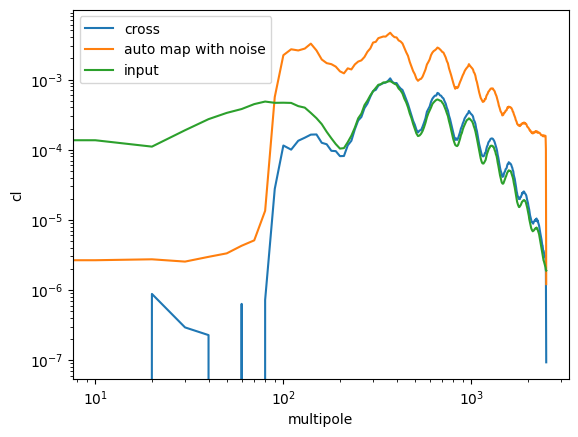

In [62]:
cl_ = ((hp.alm2cl(alms_u.astype('complex128'),k_alms[i].astype('complex128'))))
cl_ = np.array([np.mean(cl_[l_bins[i]:l_bins[i+1]]) for i in range(n_bins)])
plt.plot(l_bins[:-1],cl_, label = 'cross')

cl_ = hp.alm2cl(k_alms[i].astype('complex128'),k_alms[i].astype('complex128'))
cl_ = np.array([np.mean(cl_[l_bins[i]:l_bins[i+1]]) for i in range(n_bins)])
plt.plot(l_bins[:-1],cl_, label = 'auto map with noise')

cl_ = hp.alm2cl(alms_u.astype('complex128'))
cl_ = np.array([np.mean(cl_[l_bins[i]:l_bins[i+1]]) for i in range(n_bins)])
plt.plot(l_bins[:-1],cl_, label = 'input')
plt.xlabel('multipole')
plt.ylabel('cl')

plt.legend()
plt.xscale('log')
plt.yscale('log')

In [ ]:
hp.mollview(hp.alm2map(k_alms.astype('complex128'),nside=2048))

# more simulated maps ~~

In [ ]:
'''

For each array-frequency, we
generate 800 such simulated sky maps that are used to
calculate multiplicative and additive Monte-Carlo (MC)
biases as well as the covariance matrix (see Section 5.11)

[the above have everything]

We also generate a set of noiseless CMB simulations
used to estimate the the mean-field correction and the
RDN0 bias (see Section E.1)


 two sets of noiseless
CMB simulations with different CMB signals but with
12 We use the mnms (Map-based Noise ModelS) code available at
https://github.com/simonsobs/mnms.
13 Note that our blinding policy allows us to compare noise-biased
TT power spectra above ℓ = 500 to fiducial noise-biased power
spectra. We also note that, at this level of agreement, our bias
subtraction methods such as RDN0 (see Appendix E.1) are expected to perform well. We also note that, since these simulations
are not used to estimate foreground biases, we may approximate
them safely as Gaussian.
a common lensing field used to estimate the N1 bias (see
Section E.2). 
